# 🔍 Notebook 02: RAG at Scale — Threat Intel & Playbook Retrieval

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath("../src"))
import nest_asyncio; nest_asyncio.apply()
from soc_workshop.settings import get_settings
from soc_workshop.clients import get_project_client, configure_tracing
from soc_workshop.incident_schema import Alert, EvidenceItem, InvestigationRecord
from soc_workshop.tools.search_mock import search_threat_intel, search_playbooks
from azure.ai.projects.models import (
    PromptAgentDefinition,
    FunctionTool,
    AzureAISearchTool,
    AzureAISearchToolResource,
    AISearchIndexResource,
    AzureAISearchQueryType,
)
from openai.types.responses.response_input_param import FunctionCallOutput
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from pathlib import Path
from datetime import datetime

settings = get_settings()
configure_tracing()
project_client = get_project_client(settings)
openai_client = project_client.get_openai_client()

## The Scenario\nALERT-2025-004 indicates a credential harvesting phishing email that may have compromised user credentials. We need to retrieve matching threat intelligence and the most relevant response playbook.

In [2]:
alerts_path = Path("../data/alerts.json")
alerts = json.loads(alerts_path.read_text(encoding="utf-8"))
alert_dict = next(a for a in alerts if a["alert_id"] == "ALERT-2025-004")
alert = Alert.from_dict(dict(alert_dict))

alert_df = pd.DataFrame([alert_dict])
display(alert_df[["alert_id", "title", "severity", "timestamp", "source", "description"]])

entities_df = pd.DataFrame(alert_dict["entities"])
display(entities_df)

,alert_id,title,severity,timestamp,source,description
0,ALERT-2025-004,Credential harvesting phishing email detected,Medium,2025-03-07T09:45:00Z,Microsoft Defender for Office 365,An inbound email to jdoe@contoso.com from spoo...


,entity_type,value,risk_score,tags
0,user,jdoe@contoso.com,70,[finance-team]
1,url,https://contos0-login.evil.com/auth,98,"[phishing, credential-harvest]"
2,domain,contos0-login.evil.com,97,[phishing-domain]


## Part 1: Threat Intelligence Lookup (FunctionTool mode)

In [ ]:
# Mode A (always works): local mock search with schema-based FunctionTool
search_ti_tool = FunctionTool(
    name="search_threat_intel",
    description="Search the threat intelligence knowledge base.",
    parameters={
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "Search query for threat intel"},
            "top_k": {"type": "integer", "description": "Number of results to return"}
        },
        "required": ["query", "top_k"],
        "additionalProperties": False,
    },
    strict=True,
)

search_pb_tool = FunctionTool(
    name="search_playbooks",
    description="Search SOC response playbooks.",
    parameters={
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "Search query for playbooks"},
            "top_k": {"type": "integer", "description": "Number of results to return"}
        },
        "required": ["query", "top_k"],
        "additionalProperties": False,
    },
    strict=True,
)

analyst_instructions = (
    "You are a Threat Intelligence Analyst in a SOC. Given a security alert, search the threat "
    "intelligence knowledge base for matching IOCs, TTPs, and threat actor profiles. Also search "
    "for response playbooks that match the incident type. Always cite your sources. Produce a "
    "structured threat assessment with: Threat Summary, Matching IOCs, MITRE ATT&CK mapping, "
    "Recommended Playbook, Confidence Level."
)

agent = project_client.agents.create_version(
    agent_name="soc-02-threat-intel-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=analyst_instructions,
        tools=[search_ti_tool, search_pb_tool],
    ),
)

In [4]:
TOOL_DISPATCH = {
    "search_threat_intel": search_threat_intel,
    "search_playbooks": search_playbooks,
}

def run_agent_with_tools(openai_client, agent, user_input, tool_dispatch, max_rounds=10):
    """Run agent with manual function-call loop."""
    response = openai_client.responses.create(
        input=user_input,
        model=settings.model_deployment,
        extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
    )
    tool_call_log = []
    for _ in range(max_rounds):
        fn_calls = [item for item in response.output if item.type == "function_call"]
        if not fn_calls:
            break

        fn_outputs = []
        for call in fn_calls:
            fn = tool_dispatch.get(call.name)
            try:
                args = json.loads(call.arguments)
            except Exception:
                args = {}

            if fn is None:
                result = json.dumps({"error": f"Unknown: {call.name}"})
                parsed_result = None
            else:
                result = fn(**args)
                try:
                    parsed_result = json.loads(result)
                except Exception:
                    parsed_result = None

            tool_call_log.append({
                "tool": call.name,
                "query": args.get("query", ""),
                "top_k": args.get("top_k"),
                "results": len(parsed_result) if isinstance(parsed_result, list) else None,
            })
            fn_outputs.append(FunctionCallOutput(type="function_call_output", call_id=call.call_id, output=result))

        response = openai_client.responses.create(
            input=fn_outputs,
            previous_response_id=response.id,
            extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
        )

    return response, tool_call_log

alert_payload = {
    "alert_id": alert.alert_id,
    "title": alert.title,
    "severity": alert.severity,
    "description": alert.description,
    "tactics": alert.tactics,
    "techniques": alert.techniques,
    "entities": [{"entity_type": e.entity_type, "value": e.value, "tags": e.tags} for e in alert.entities],
}

response, tool_call_log = run_agent_with_tools(
    openai_client,
    agent,
    "Investigate this phishing alert and produce a structured threat assessment with citations:\n" + json.dumps(alert_payload, indent=2),
    TOOL_DISPATCH,
)
assessment_text = response.output_text
display(Markdown("### Threat Assessment\n" + assessment_text))

### Threat Assessment
## Structured Threat Assessment: ALERT-2025-004

### Threat Summary
A phishing email was sent to jdoe@contoso.com from the spoofed address hr-benefits@contos0.com. The email contained a link to https://contos0-login.evil.com/auth, which mimics the legitimate Contoso Entra ID login portal for the purpose of credential harvesting. This campaign uses typosquatting ("contos0" instead of "contoso") and closely clones the brand experience to deceive users. If credentials are entered, attackers often attempt sign-ins within minutes, likely seeking to establish persistence or further access via the user's account, particularly as the target is a member of the finance team.

---

### Matching IOCs
- Spoofed sender: hr-benefits@contos0.com
- Phishing URL: https://contos0-login.evil.com/auth
- Phishing domain: contos0-login.evil.com

Referenced in:
- PhishLabs Quarterly Report Q1 2025: "Credential harvesting campaigns in Q1 2025 heavily leverage typosquat domains targeting Microsoft 365 tenants ... patterns include replacing 'o' with '0' (contoso → contos0) ... After credential capture, attackers immediately attempt sign-in ..." ([PhishLabs Q1 2025](#sources))
- Microsoft Threat Intelligence: "Threat actors are increasingly using TOR exit nodes for credential-based attacks against Entra ID. In recent campaigns, attackers first harvest credentials via phishing (T1566.002) ..." ([Microsoft Threat Intelligence](#sources))

---

### MITRE ATT&CK Mapping

- **Tactic:** Initial Access
- **Technique:** T1566.002 – Phishing: Spearphishing Link ([MITRE](https://attack.mitre.org/techniques/T1566/002/))

These campaigns match documented patterns of spearfishing links targeting Entra ID (M365), often shortly followed by sign-in attempts from unusual locations or TOR.

---

### Recommended Playbook

**Phishing Email with Credential Harvesting — Response Playbook** ([Playbook PB-001](#sources))

#### Key Steps:
1. **Triage:** Confirm phishing; determine if user clicked the link/entered credentials.
2. **Containment:** If credentials compromised, force password reset, revoke tokens, disable account, block the phishing URL/domain, and purge emails across mailboxes.
3. **Investigation:** Review sign-in logs (look for TOR/VPN/geolocation abnormality, new inbox rules, app consents).
4. **Eradication:** Remove persistence mechanisms (rules, app consents), enforce MFA.
5. **Recovery:** Re-enable account with new credentials and MFA, monitor for 72 hours, and brief the user.

- **Severity guide:** Clicked link = Medium; credentials entered (no sign-in) = Medium-High; credentials entered + attacker sign-in = High.

---

### Confidence Level

- **High**: The use of a typosquat domain mimicking Entra ID, activity targeting a financial user, and documented patterns all validate this as a genuine credential harvesting phishing attempt.
- Sources include sector-relevant threat intelligence (PhishLabs, Microsoft Threat Intelligence), consistent MITRE ATT&CK alignment, and playbook applicability.

---

### Sources

1. PhishLabs Quarterly Report Q1 2025: "Phishing Typosquat Domain Patterns for M365 Credential Harvesting"  
2. Microsoft Threat Intelligence: "TOR Exit Node Abuse in Credential Theft Campaigns"  
3. Playbook PB-001: "Phishing Email with Credential Harvesting — Response Playbook"  
4. [MITRE ATT&CK T1566.002](https://attack.mitre.org/techniques/T1566/002/)

---

**Next Steps**: Follow Playbook PB-001 to confirm user interaction, contain and eradicate any compromise, and investigate for lateral movement or persistence indicators. 

If you need full response procedures or IOC block lists, please request.

In [5]:
threat_docs = []
playbook_docs = []

tool_df = pd.DataFrame(tool_call_log)
display(tool_df if not tool_df.empty else pd.DataFrame([{"tool": "(no tool calls captured)"}]))

,tool,query,top_k,results
0,search_threat_intel,phishing credential harvesting T1566.002 https...,5,3
1,search_playbooks,phishing credential harvesting response Contoso,3,3


## Part 2: Azure AI Search Integration (Live mode)\nThis is the production pattern. If search connection settings are missing, the notebook safely stays in mock mode.

In [ ]:
live_agent = None
if settings.search_connection_name and settings.search_index_name:
    conn = project_client.connections.get(connection_name=settings.search_connection_name)
    ai_search_tool = AzureAISearchTool(
        azure_ai_search=AzureAISearchToolResource(
            indexes=[
                AISearchIndexResource(
                    project_connection_id=conn.id,
                    index_name=settings.search_index_name,
                    query_type=AzureAISearchQueryType.SEMANTIC,
                    top_k=5,
                )
            ]
        )
    )
    live_agent = project_client.agents.create_version(
        agent_name="soc-02-threat-intel-analyst-live",
        definition=PromptAgentDefinition(
            model=settings.model_deployment,
            instructions=analyst_instructions,
            tools=[ai_search_tool],
        ),
    )
    display(Markdown(f"✅ Live Azure AI Search agent ready (index: `{settings.search_index_name}`)."))
else:
    display(Markdown("⚠️ Live mode skipped: set `AZURE_AI_SEARCH_CONNECTION_NAME` and `AZURE_AI_SEARCH_INDEX_NAME` in .env."))

⚠️ Live mode skipped: set `AZURE_AI_SEARCH_CONNECTION_NAME` and `AZURE_AI_SEARCH_INDEX_NAME` in .env.

## Comparing Results: Mock vs Live Search

C:\Users\haozhang2\AppData\Local\Temp\ipykernel_45088\24368663.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=severity_counts, x="severity", y="document_count", ax=axes[0], palette="viridis")
C:\Users\haozhang2\AppData\Local\Temp\ipykernel_45088\24368663.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=score_df, y="title", x="relevance_score", ax=axes[1], palette="magma")


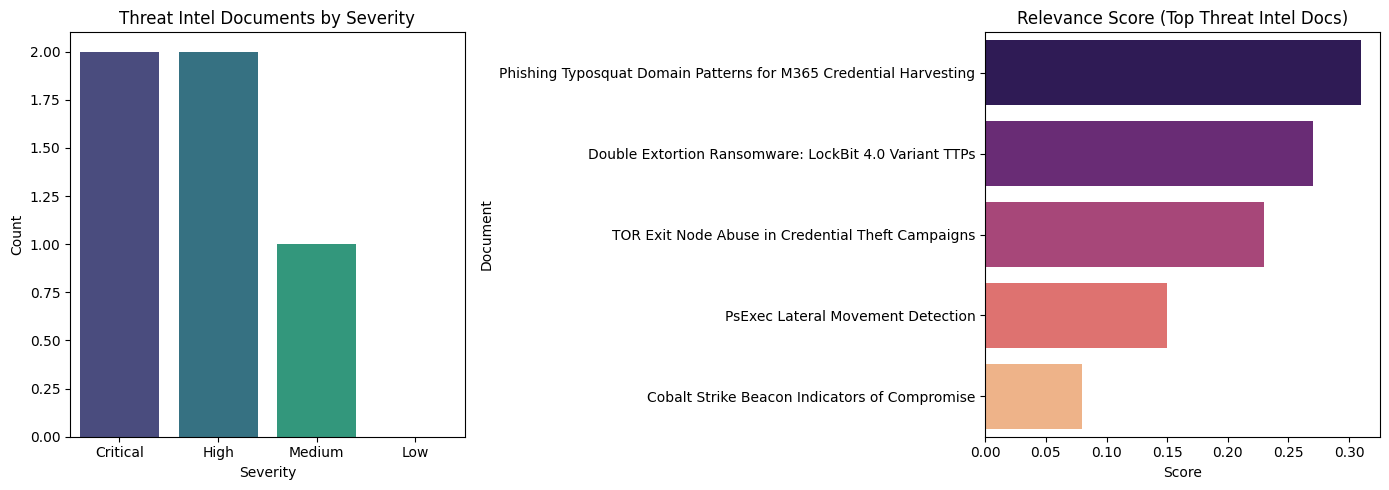

In [7]:
# Fallback so charts/checklists still render even if run-step parsing misses outputs
if not threat_docs:
    fallback_query = f"{alert.title} {alert.description} {' '.join(e.value for e in alert.entities)}"
    threat_docs = json.loads(search_threat_intel(fallback_query, top_k=5))
if not playbook_docs:
    playbook_docs = json.loads(search_playbooks(alert.description, top_k=3))

threat_df = pd.DataFrame(threat_docs)
if threat_df.empty:
    threat_df = pd.DataFrame(columns=["id", "title", "source", "severity", "relevance_score", "content"])

severity_order = ["Critical", "High", "Medium", "Low"]
severity_counts = (
    threat_df.assign(severity=threat_df.get("severity", pd.Series(dtype=str)).fillna("Low"))
    .groupby("severity", as_index=False)
    .size()
    .rename(columns={"size": "document_count"})
)
severity_counts["severity"] = pd.Categorical(severity_counts["severity"], categories=severity_order, ordered=True)
severity_counts = severity_counts.sort_values("severity")

score_df = threat_df[["title", "relevance_score"]].copy() if not threat_df.empty else pd.DataFrame(columns=["title", "relevance_score"])
score_df["relevance_score"] = pd.to_numeric(score_df["relevance_score"], errors="coerce").fillna(0.0)
score_df = score_df.sort_values("relevance_score", ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=severity_counts, x="severity", y="document_count", ax=axes[0], palette="viridis")
axes[0].set_title("Threat Intel Documents by Severity")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Count")

sns.barplot(data=score_df, y="title", x="relevance_score", ax=axes[1], palette="magma")
axes[1].set_title("Relevance Score (Top Threat Intel Docs)")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Document")

plt.tight_layout()
plt.show()

In [8]:
playbook_df = pd.DataFrame(playbook_docs)
display(playbook_df[["id", "title", "severity", "relevance_score"]] if not playbook_df.empty else pd.DataFrame(columns=["id", "title", "severity", "relevance_score"]))

checklist_lines = ["### Matched Playbook Checklist"]
for _, row in playbook_df.sort_values("relevance_score", ascending=False).iterrows():
    checklist_lines.append(f"\n**{row.get('title', 'Playbook')}** ({row.get('source', 'n/a')})")
    content = str(row.get("content", ""))
    for step in [s.strip() for s in content.split(".") if s.strip()]:
        checklist_lines.append(f"- [ ] {step}.")

display(Markdown("\n".join(checklist_lines)))

,id,title,severity,relevance_score
0,PB-001,Phishing Email with Credential Harvesting — Re...,Medium-High,0.27
1,PB-003,Compromised Account with Lateral Movement — Re...,High-Critical,0.18
2,PB-002,Ransomware Outbreak — Response Playbook,Critical,0.14


### Matched Playbook Checklist

**Phishing Email with Credential Harvesting — Response Playbook** (n/a)
- [ ] **Objective:** Contain credential compromise from phishing and prevent lateral movement.
- [ ] **Step 1 — Triage (5 min):** Confirm phishing email via Defender for Office 365.
- [ ] Check if user clicked the link (URL trace).
- [ ] Check if credentials were entered (sign-in logs from suspicious IP within 30 min of click).
- [ ] **Step 2 — Containment (15 min):** If credentials compromised: force password reset, revoke all refresh tokens, disable account temporarily.
- [ ] Block the phishing URL and domain at proxy/firewall.
- [ ] Purge the email from all mailboxes via Content Search.
- [ ] **Step 3 — Investigation (30 min):** Review sign-in logs for the user — look for TOR, VPN, unusual geo.
- [ ] Check for new inbox rules (forwarding to external).
- [ ] Check for OAuth app consent grants.
- [ ] Look for lateral movement from the user's account.
- [ ] **Step 4 — Eradication:** Remove any inbox rules or app consents created by attacker.
- [ ] Ensure MFA is enforced.
- [ ] Review conditional access policies.
- [ ] **Step 5 — Recovery:** Re-enable account with fresh credentials + MFA.
- [ ] Monitor for 72 hours.
- [ ] Brief the user on what happened.
- [ ] **Severity guide:** Clicked link only = Medium.
- [ ] Credentials entered, no sign-in = Medium-High.
- [ ] Credentials entered + attacker sign-in = High.
- [ ] Lateral movement detected = Critical.

**Compromised Account with Lateral Movement — Response Playbook** (n/a)
- [ ] **Objective:** Contain compromised identity and prevent further lateral movement.
- [ ] **Step 1 — Triage (10 min):** Identify the compromised account and initial access method.
- [ ] Determine if it's a standard user, service account, or privileged account.
- [ ] Check what systems the account has accessed since compromise.
- [ ] **Step 2 — Containment (IMMEDIATE for privileged accounts):** Disable the compromised account.
- [ ] Revoke all sessions and tokens.
- [ ] If service account: identify dependent services before disabling (coordinate with ops).
- [ ] Block source IPs used by attacker.
- [ ] **Step 3 — Investigation:** Map lateral movement path: source host → intermediate hosts → targets.
- [ ] For each host accessed: check for persistence (scheduled tasks, services, registry run keys).
- [ ] Check for credential dumping (LSASS access, Mimikatz artifacts).
- [ ] Check for data access/staging/exfiltration.
- [ ] **Step 4 — Scope Assessment:** List all credentials that were available on compromised hosts (cached, stored, service).
- [ ] Assume all credentials on compromised hosts are stolen.
- [ ] Check for Golden Ticket / Silver Ticket indicators if DC was accessed.
- [ ] **Step 5 — Eradication:** Reset all compromised credentials.
- [ ] Remove persistence mechanisms from all accessed hosts.
- [ ] If Tier 0 compromise: full krbtgt reset, review AD for backdoor accounts.
- [ ] **Step 6 — Recovery:** Re-enable accounts with new credentials + MFA enforced.
- [ ] Implement additional monitoring on affected accounts for 30 days.
- [ ] **Escalation triggers:** Service account compromised, Domain admin compromised, Domain controller accessed, More than 5 hosts in lateral movement chain.

**Ransomware Outbreak — Response Playbook** (n/a)
- [ ] **Objective:** Contain ransomware spread, preserve evidence, and begin recovery.
- [ ] **Step 1 — Triage (IMMEDIATE):** Identify patient zero (first encrypted host).
- [ ] Determine ransomware variant from file extension, ransom note, or binary hash.
- [ ] Assess blast radius — how many hosts/shares affected?

**Step 2 — Containment (15 min — CRITICAL):** Isolate patient zero from network (Defender Live Response or network switch).
- [ ] Disable the compromised user account(s).
- [ ] Block C2 IPs and exfil domains at perimeter.
- [ ] If domain admin credentials compromised: disable the account, consider disabling the computer object.
- [ ] **Step 3 — Evidence Preservation:** Before reimaging, collect: memory dump, encrypted file samples, ransom note, process tree, network connections, event logs.
- [ ] Preserve the Cobalt Strike beacon binary if found.
- [ ] **Step 4 — Investigation (parallel with containment):** Build attack timeline: initial access → persistence → lateral movement → exfil → encryption.
- [ ] Identify all compromised accounts.
- [ ] Check for data exfiltration (cloud upload, DNS tunneling).
- [ ] Determine if domain controller was accessed — if so, assume full domain compromise.
- [ ] **Step 5 — Eradication:** Reimage affected hosts.
- [ ] Reset ALL compromised credentials.
- [ ] If DC accessed: reset krbtgt (twice, 10-hour interval), rebuild domain trust.
- [ ] Patch the initial access vector.
- [ ] **Step 6 — Recovery:** Restore from clean backups (verify backup integrity first).
- [ ] Re-join reimaged hosts to domain.
- [ ] Gradual reconnection with monitoring.
- [ ] **DO NOT:** Pay ransom without executive/legal approval.
- [ ] Reimage before collecting evidence.
- [ ] Assume scope is limited to encrypted hosts.
- [ ] **Severity: ALWAYS Critical.
- [ ] **.

In [9]:
# Build updated investigation record with threat-intel evidence
record = InvestigationRecord(
    incident_id=alert.alert_id,
    title=alert.title,
    alerts=[alert],
    entities=alert.entities,
    hypothesis="Credential harvesting phishing likely attempted account compromise.",
    verdict="True Positive",
    confidence=0.78,
    recommended_actions=[
        "Reset affected user credentials",
        "Revoke active sessions and require MFA re-registration",
        "Block phishing domain and URL across controls",
    ],
)

for doc in threat_docs:
    record.evidence.append(EvidenceItem(
        source=doc.get("source", "threat_intel"),
        category="threat_intel",
        summary=f"{doc.get('title', 'Threat intel document')} (score={doc.get('relevance_score', 0)})",
        raw=doc,
        timestamp=datetime.utcnow().isoformat()
    ))

record_path = Path("../data/investigation_02.json")
record_path.write_text(record.to_json(indent=2), encoding="utf-8")
display(pd.DataFrame([{
    "incident_id": record.incident_id,
    "evidence_items": len(record.evidence),
    "saved_to": str(record_path)
}]))

C:\Users\haozhang2\AppData\Local\Temp\ipykernel_45088\1060933046.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.utcnow().isoformat()


,incident_id,evidence_items,saved_to
0,ALERT-2025-004,5,..\data\investigation_02.json


### (optional) Cleanup

In [ ]:
# uncomment to Cleanup
# try:
#     if live_agent is not None:
#         project_client.agents.delete_version(agent_name=live_agent.name, agent_version=live_agent.version)
# except Exception:
#     pass

# project_client.agents.delete_version(agent_name=agent.name, agent_version=agent.version)
# openai_client.close()

## Summary of this notebook
- Load a phishing alert and run a threat-intel agent with FunctionTools for intel and playbook search.
- Optionally switch to Azure AI Search live mode and compare mock vs live results.
- Visualize threat intel coverage, generate a playbook checklist, and save investigation_02.json.

## What's Next\nProceed to **Notebook 03** to pivot from intelligence retrieval into response orchestration and automated containment decisions.